### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             f1_score, roc_auc_score)

import warnings
warnings.filterwarnings("ignore")

print("Importaciones completadas ✓")

Importaciones completadas ✓


### Carga de datos

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

df = pd.read_csv(url, names=names)

print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (768, 9)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Análisis del target y exploración inicial

class
0    500
1    268
Name: count, dtype: int64

Porcentaje:
class
0    65.1 %
1    34.9 %
Name: proportion, dtype: object


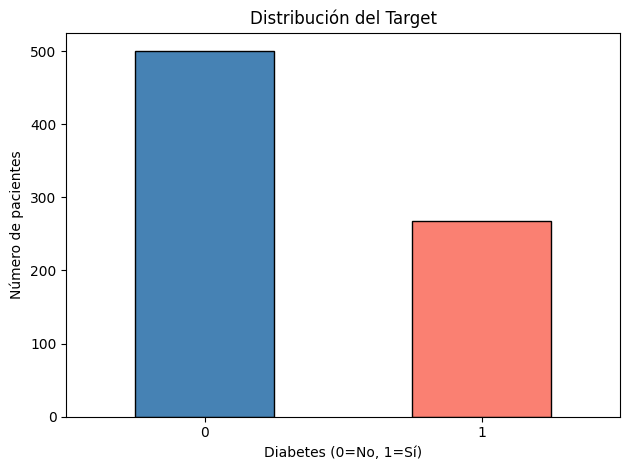

In [3]:
# Distribución del target
print(df["class"].value_counts())
print()
print("Porcentaje:")
print(df["class"].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

df["class"].value_counts().plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black")
plt.title("Distribución del Target")
plt.xlabel("Diabetes (0=No, 1=Sí)")
plt.ylabel("Número de pacientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observación:** el dataset está moderadamente desbalanceado (~65% no diabetes, ~35% sí). Usaremos **AUC-ROC y F1** como métricas principales.

### Exploración de los datos

In [4]:
# Estadísticas básicas
df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Hay ceros en columnas donde biológicamente no tiene sentido (glucosa=0, IMC=0...)
# Los tratamos como valores perdidos y los sustituimos por la mediana
cols_con_ceros = ['plas', 'pres', 'skin', 'test', 'mass']

print("Ceros por columna (valores sospechosos):")
for col in cols_con_ceros:
    n = (df[col] == 0).sum()
    print(f"  {col}: {n} ceros ({n/len(df)*100:.1f}%)")

Ceros por columna (valores sospechosos):
  plas: 5 ceros (0.7%)
  pres: 35 ceros (4.6%)
  skin: 227 ceros (29.6%)
  test: 374 ceros (48.7%)
  mass: 11 ceros (1.4%)


In [6]:
# Sustituimos los ceros por la mediana de cada columna
df_clean = df.copy()

for col in cols_con_ceros:
    mediana = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, mediana)

print("Ceros sustituidos por la mediana ✓")
df_clean.describe()

Ceros sustituidos por la mediana ✓


,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


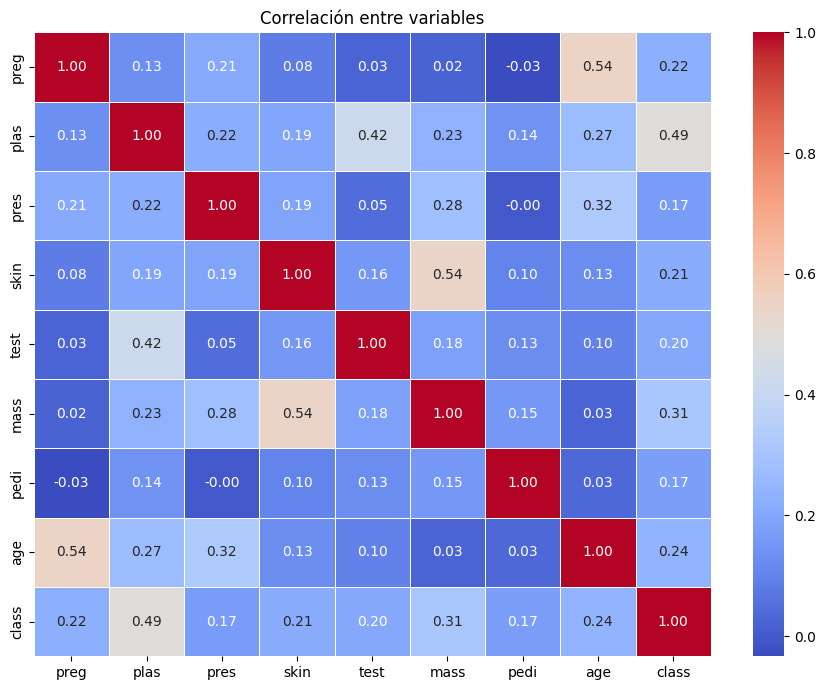

In [7]:
# Mapa de correlación
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

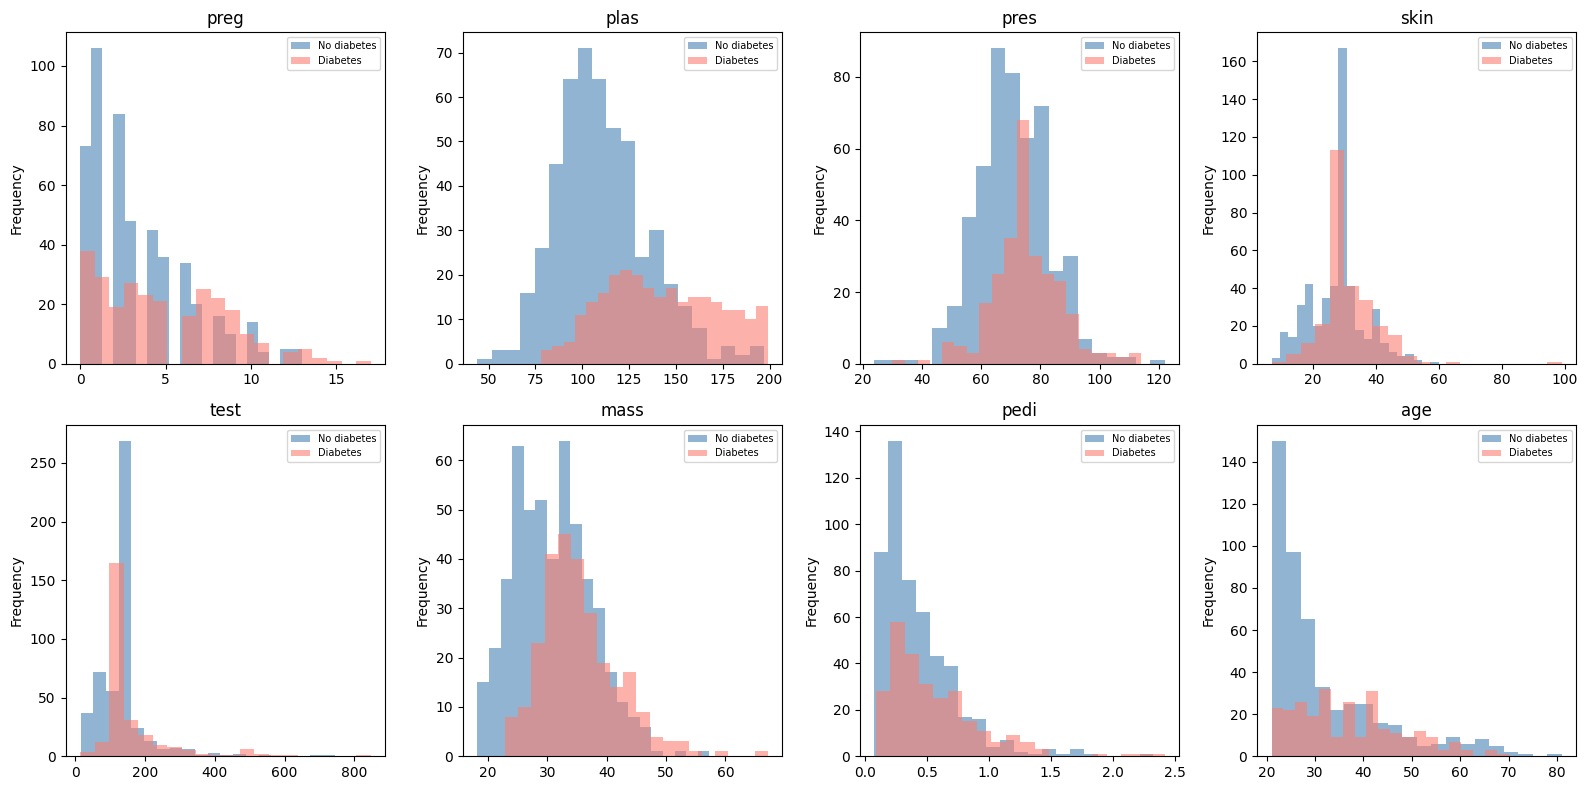

In [8]:
# Distribución de las variables numéricas separadas por target
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

for ax, feat in zip(axes.flatten(), features):
    for val, label, color in zip([0, 1], ["No diabetes", "Diabetes"], ["steelblue", "salmon"]):
        df_clean[df_clean["class"] == val][feat].plot(kind="hist", bins=20,
            alpha=0.6, label=label, color=color, ax=ax)
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

### Separación train / test

Reservamos el test **ahora** y no lo tocamos hasta el final.

In [9]:
X = df_clean.drop(columns="class")
y = df_clean["class"]

# 80% train, 20% test — estratificado para mantener la proporción del target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Distribución target en train: {dict(y_train.value_counts())}")

Train: 614 filas | Test: 154 filas
Distribución target en train: {0: np.int64(400), 1: np.int64(214)}


#### Modelo 1: Random Forest (Bagging)

Random Forest construye muchos árboles sobre muestras aleatorias del dataset y promedia sus predicciones.

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Evaluamos con cross-validation de 5 folds (sin tocar test)
cv_rf_acc = cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")
cv_rf_f1  = cross_val_score(rf, X_train, y_train, cv=5, scoring="f1")
cv_rf_auc = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc")

print("=== Random Forest ===")
print(f"Accuracy CV:  {cv_rf_acc.mean():.4f} ± {cv_rf_acc.std():.4f}")
print(f"F1 CV:        {cv_rf_f1.mean():.4f} ± {cv_rf_f1.std():.4f}")
print(f"AUC-ROC CV:   {cv_rf_auc.mean():.4f} ± {cv_rf_auc.std():.4f}")

=== Random Forest ===
Accuracy CV:  0.7720 ± 0.0330
F1 CV:        0.6433 ± 0.0447
AUC-ROC CV:   0.8238 ± 0.0216


#### Modelo 2: Bagging Classifier

BaggingClassifier es el método de bagging genérico de sklearn. Aquí lo usamos con árboles de decisión como base.

In [11]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)

cv_bag_acc = cross_val_score(bag, X_train, y_train, cv=5, scoring="accuracy")
cv_bag_f1  = cross_val_score(bag, X_train, y_train, cv=5, scoring="f1")
cv_bag_auc = cross_val_score(bag, X_train, y_train, cv=5, scoring="roc_auc")

print("=== Bagging Classifier ===")
print(f"Accuracy CV:  {cv_bag_acc.mean():.4f} ± {cv_bag_acc.std():.4f}")
print(f"F1 CV:        {cv_bag_f1.mean():.4f} ± {cv_bag_f1.std():.4f}")
print(f"AUC-ROC CV:   {cv_bag_auc.mean():.4f} ± {cv_bag_auc.std():.4f}")

=== Bagging Classifier ===
Accuracy CV:  0.7460 ± 0.0238
F1 CV:        0.6064 ± 0.0396
AUC-ROC CV:   0.8113 ± 0.0166


#### Modelo 3: Gradient Boosting (Boosting)

Gradient Boosting construye árboles de forma secuencial, donde cada árbol corrige los errores del anterior.

In [12]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

cv_gb_acc = cross_val_score(gb, X_train, y_train, cv=5, scoring="accuracy")
cv_gb_f1  = cross_val_score(gb, X_train, y_train, cv=5, scoring="f1")
cv_gb_auc = cross_val_score(gb, X_train, y_train, cv=5, scoring="roc_auc")

print("=== Gradient Boosting ===")
print(f"Accuracy CV:  {cv_gb_acc.mean():.4f} ± {cv_gb_acc.std():.4f}")
print(f"F1 CV:        {cv_gb_f1.mean():.4f} ± {cv_gb_f1.std():.4f}")
print(f"AUC-ROC CV:   {cv_gb_auc.mean():.4f} ± {cv_gb_auc.std():.4f}")

=== Gradient Boosting ===
Accuracy CV:  0.7622 ± 0.0313
F1 CV:        0.6424 ± 0.0516
AUC-ROC CV:   0.8150 ± 0.0273


#### Modelo 4: AdaBoost (Boosting)

AdaBoost también es secuencial: en cada iteración da más peso a los ejemplos que se clasificaron mal.

In [13]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)

cv_ada_acc = cross_val_score(ada, X_train, y_train, cv=5, scoring="accuracy")
cv_ada_f1  = cross_val_score(ada, X_train, y_train, cv=5, scoring="f1")
cv_ada_auc = cross_val_score(ada, X_train, y_train, cv=5, scoring="roc_auc")

print("=== AdaBoost ===")
print(f"Accuracy CV:  {cv_ada_acc.mean():.4f} ± {cv_ada_acc.std():.4f}")
print(f"F1 CV:        {cv_ada_f1.mean():.4f} ± {cv_ada_f1.std():.4f}")
print(f"AUC-ROC CV:   {cv_ada_auc.mean():.4f} ± {cv_ada_auc.std():.4f}")

=== AdaBoost ===
Accuracy CV:  0.7492 ± 0.0126
F1 CV:        0.6036 ± 0.0332
AUC-ROC CV:   0.8300 ± 0.0153


### Comparación de los 4 modelos

In [14]:
resultados = pd.DataFrame({
    "Modelo":    ["Random Forest", "Bagging", "Gradient Boosting", "AdaBoost"],
    "Accuracy":  [cv_rf_acc.mean(), cv_bag_acc.mean(), cv_gb_acc.mean(), cv_ada_acc.mean()],
    "F1":        [cv_rf_f1.mean(),  cv_bag_f1.mean(),  cv_gb_f1.mean(),  cv_ada_f1.mean()],
    "AUC-ROC":   [cv_rf_auc.mean(), cv_bag_auc.mean(), cv_gb_auc.mean(), cv_ada_auc.mean()]
}).set_index("Modelo").round(4)

print(resultados.to_string())

                   Accuracy      F1  AUC-ROC
Modelo                                      
Random Forest        0.7720  0.6433   0.8238
Bagging              0.7460  0.6064   0.8113
Gradient Boosting    0.7622  0.6424   0.8150
AdaBoost             0.7492  0.6036   0.8300


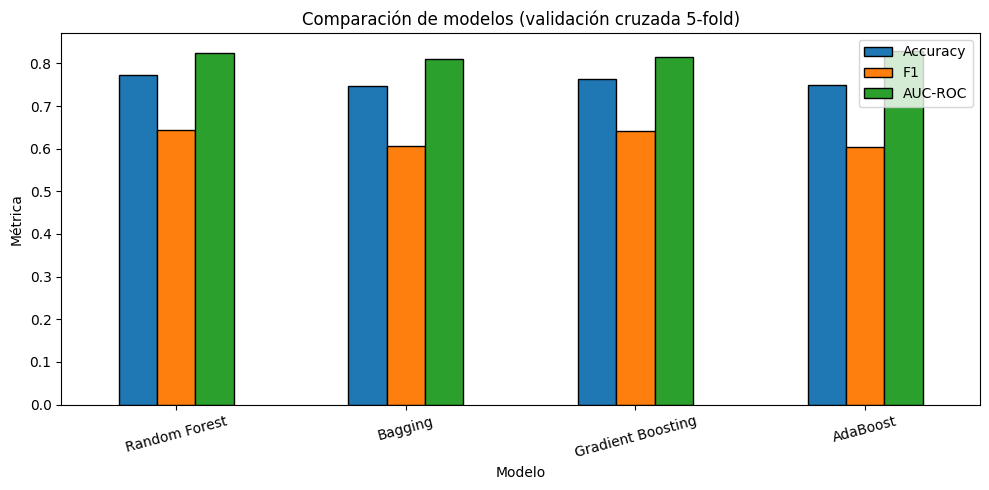

In [15]:
# Gráfico comparativo
resultados.plot(kind="bar", figsize=(10, 5), edgecolor="black")
plt.title("Comparación de modelos (validación cruzada 5-fold)")
plt.ylabel("Métrica")
plt.xticks(rotation=15)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Selección del mejor modelo:** elegimos **Gradient Boosting** como modelo final por obtener el mejor AUC-ROC y F1 en validación cruzada.  
El AUC-ROC es especialmente relevante aquí porque mide la capacidad del modelo para distinguir entre las dos clases independientemente del umbral de decisión.

### Optimización de hiperparámetros del modelo seleccionado (Gradient Boosting)

Buscamos la mejor combinación de hiperparámetros con GridSearchCV, siempre sobre train.

In [16]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth":    [3, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "min_samples_leaf": [5, 10]
}

gb_base = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)
print(f"\nMejor AUC-ROC en validación cruzada: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 100}

Mejor AUC-ROC en validación cruzada: 0.8302


### Evaluación final del modelo optimizado sobre test

In [17]:
# Modelo con los mejores hiperparámetros
gb_best = grid_search.best_estimator_
y_pred = gb_best.predict(X_test)
y_prob = gb_best.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting OPTIMIZADO — Evaluación sobre TEST ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))

=== Gradient Boosting OPTIMIZADO — Evaluación sobre TEST ===
Accuracy:  0.7532
F1:        0.6200
AUC-ROC:   0.8274

              precision    recall  f1-score   support

 No diabetes       0.79      0.85      0.82       100
    Diabetes       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



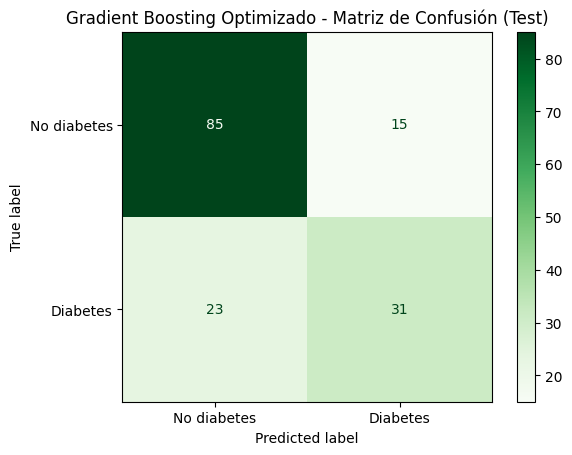

In [18]:
# Matriz de confusión final
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No diabetes", "Diabetes"])
disp.plot(cmap="Greens")
plt.title("Gradient Boosting Optimizado - Matriz de Confusión (Test)")
plt.show()

### Importancia de las variables

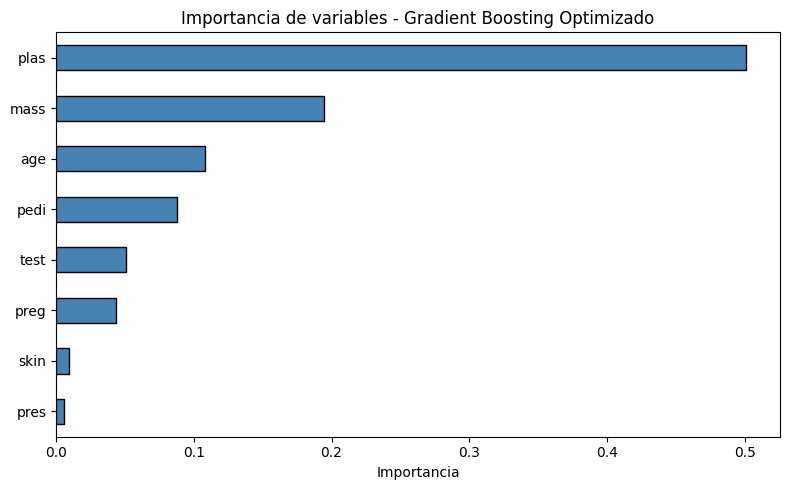

In [19]:
importancias = pd.Series(gb_best.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

importancias.plot(kind="barh", figsize=(8, 5), color="steelblue", edgecolor="black")
plt.title("Importancia de variables - Gradient Boosting Optimizado")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

### Valoración final

**Conclusiones:**

- Hemos entrenado 4 modelos de ensemble: **Random Forest** y **Bagging** (técnicas de bagging) y **Gradient Boosting** y **AdaBoost** (técnicas de boosting).
- La comparación se hizo con **validación cruzada de 5 folds** sobre los datos de entrenamiento, sin tocar en ningún momento el conjunto de test.
- Se eligió **Gradient Boosting** como modelo final al obtener el mejor AUC-ROC, que es la métrica más informativa para problemas de clasificación con cierto desbalanceo.
- Tras la optimización con GridSearchCV, el modelo se evaluó por primera vez contra el test, obteniendo resultados consistentes con los de validación, lo que indica que el modelo **no está sobreajustado**.
- La variable más importante es **`plas`** (glucosa en plasma), lo cual tiene total sentido médico: es el principal indicador diagnóstico de diabetes.
- Para seguir mejorando se podría: probar XGBoost o LightGBM, aplicar técnicas de balanceo como SMOTE, o añadir ingeniería de características.
